In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import Levenshtein
from scipy.stats import chi2_contingency
import warnings
from scipy.stats import linregress, pointbiserialr
import seaborn as sns
%matplotlib inline

In [2]:
warnings.filterwarnings("ignore")

In [3]:
pd.options.display.max_columns = None

In [4]:
df = pd.read_csv("../data/cleaned_data.csv")

In [5]:
df.dtypes

transaction_id                   str
customer_id                      str
timestamp                        str
home_country                     str
source_currency                  str
dest_currency                    str
channel                          str
amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                        str
new_device                      bool
ip_address                       str
ip_country                       str
location_mismatch               bool
ip_risk_score                float64
kyc_tier                         str
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
datetime                         str
d

In [6]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                       0
dtype: int64

In [7]:
df.datetime = pd.to_datetime(df.datetime)

In [8]:
df.groupby(by = df.datetime.dt.to_period("Q"))["transaction_id"].count()

datetime
2022Q4     852
2023Q1     823
2023Q2     842
2023Q3     831
2023Q4     926
2024Q1    1012
2024Q2    1030
2024Q3     951
2024Q4    1011
2025Q1     945
2025Q2    1005
2025Q3    1033
2025Q4     139
Freq: Q-DEC, Name: transaction_id, dtype: int64

In [9]:
df.groupby(by = df.datetime.dt.to_period("Q"))["is_fraud"].mean().round(4) * 100

datetime
2022Q4     1.76
2023Q1     2.19
2023Q2     1.43
2023Q3     1.93
2023Q4     5.18
2024Q1     9.98
2024Q2    12.43
2024Q3    13.04
2024Q4    12.76
2025Q1    11.22
2025Q2    10.55
2025Q3    11.52
2025Q4    53.96
Freq: Q-DEC, Name: is_fraud, dtype: float64

In [10]:
df.is_fraud.mean().round(4) * 100

np.float64(8.75)

In [11]:
traxn_by_qt = df.groupby(by = df.datetime.dt.to_period("Q"))["transaction_id"].count().to_frame()

In [12]:
traxn_by_qt.rename(columns = {"transaction_id": "count"}, inplace = True)

In [13]:
traxn_by_qt["%volume"] = ((traxn_by_qt["count"] / traxn_by_qt["count"].sum()).round(4) * 100).cumsum()

In [14]:
traxn_by_qt

,count,%volume
datetime,,
2022Q4,852,7.47
2023Q1,823,14.69
2023Q2,842,22.08
2023Q3,831,29.37
2023Q4,926,37.49
2024Q1,1012,46.37
2024Q2,1030,55.41
2024Q3,951,63.75
2024Q4,1011,72.62


In [15]:
train_valid_df = df.loc[
    df.datetime.dt.to_period("Q") <= "2025Q1"
].reset_index(drop = True)

In [16]:
test_df = df.loc[
    df.datetime.dt.to_period("Q") > "2025Q1"
].reset_index(drop = True)

In [17]:
df.shape, train_valid_df.shape, test_df.shape

((11400, 27), (9223, 27), (2177, 27))

In [18]:
train_valid_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022-10-03 18:40:59.468549+00:00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022-10-03 20:39:38.468549+00:00
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022-10-03 23:02:43.468549+00:00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022-10-04 01:08:53.468549+00:00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022-10-04 09:35:03.468549+00:00


In [19]:
device_trust_score = pd.merge(
    train_valid_df.groupby(by = "customer_id").aggregate({"device_trust_score": "nunique"}).rename(columns = {"device_trust_score": "score_counts"}),
    train_valid_df.groupby(by = "customer_id").aggregate({"device_id": "nunique"}).rename(columns = {"device_id": "device_counts"}),
    how = "inner",
    left_index = True,
    right_index = True
)

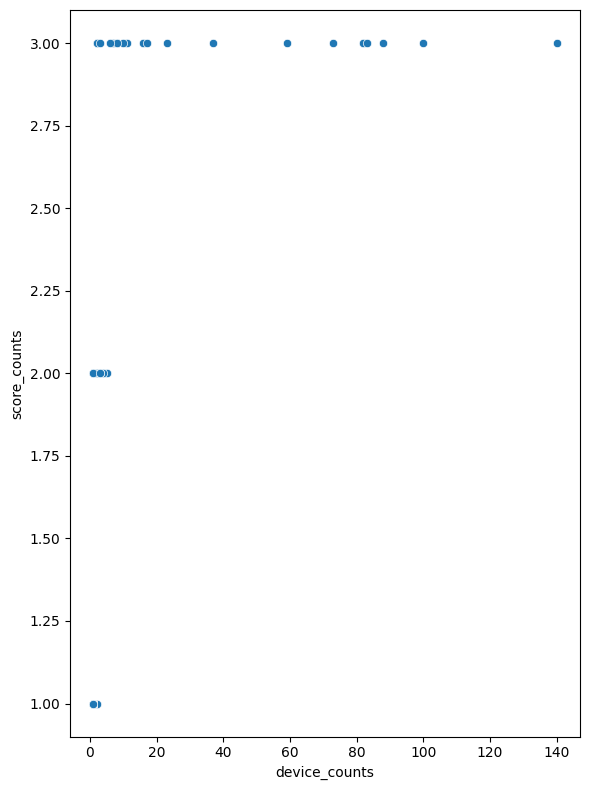

In [20]:
fig, ax = plt.subplots(figsize = (6, 8))

sns.scatterplot(data = device_trust_score, x = "device_counts", y = "score_counts", ax = ax)

plt.tight_layout()
plt.show()

In [21]:
device_score_counts = pd.merge(
    train_valid_df.groupby(by = ["customer_id"]).aggregate({"device_trust_score": "nunique"}).rename(columns = {"device_trust_score": "counts"}),
    train_valid_df.groupby(by = ["customer_id"]).aggregate({"device_trust_score": "unique"}).rename(columns = {"device_trust_score": "scores"}),
    how = "inner", left_index = True, right_index = True
).sort_values(by = ["counts"], ascending = [False])

In [22]:
device_score_counts.head(10)

,counts,scores
customer_id,,
402cccc9-28de-45b3-9af7-cc5302aa1f93,3,"[0.522, -0.1, 0.372]"
4cfe5cbc-d677-49bc-8739-b1d05f351250,3,"[0.702, -0.1, 0.552]"
4dfeffe2-94ed-4fc3-b5bc-89c6f1e86dab,3,"[0.867, 0.717, -0.1]"
c6d6f094-e982-46d2-8c1b-12d3af4a4bb9,3,"[0.881, 0.731, -0.1]"
70a93d26-8e3a-4179-900c-a4a7a74d08e5,3,"[0.894, 0.744, -0.1]"
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,3,"[0.892, 0.742, -0.1]"
af8ca4c4-8703-4c55-b66c-2b76cd70040d,3,"[0.934, 0.784, -0.1]"
7795eb78-a695-44b8-932b-0217a5085912,3,"[0.515, 0.365, -0.1]"
140d2232-ee97-4934-81aa-9e5c323d7c6f,3,"[0.607, -0.1, 0.457]"


In [23]:
device_score_counts.loc[device_score_counts.counts == 2]

,counts,scores
customer_id,,
62dc9fd8-0412-4a44-86fb-777339324bf3,2,"[-0.1, 0.655]"
9ca86bcd-7fa3-4d13-aa8e-a973183c2189,2,"[0.777, 0.627]"
691bb730-3142-40b3-a64f-0e54dc199252,2,"[0.687, 0.783]"
d63571e6-4a0b-4339-9d12-3dd2f2c07d13,2,"[0.658, 0.508]"
2e10ce45-893c-4f63-b30b-ca9db2437f82,2,"[0.75, 0.6]"
e2877c2a-0447-4875-9ca3-a8df7b780396,2,"[0.672, 0.822]"
51cd1837-b264-47cf-9b38-bf74ede21f0e,2,"[0.833, 0.683]"
2977967f-676c-4644-92ca-e4fb348285c7,2,"[0.515, 0.365]"
95de1ea4-0f12-4380-b781-16b6a490bebd,2,"[0.923, 0.773]"


In [24]:
pd.merge(
    train_valid_df.loc[(~train_valid_df.new_device) & (train_valid_df.device_trust_score > 0)].groupby(by = ["customer_id"]).aggregate({"device_trust_score": "unique"}).rename(columns = {"device_trust_score": "old"}),
    train_valid_df.loc[(train_valid_df.new_device) & (train_valid_df.device_trust_score > 0)].groupby(by = ["customer_id"]).aggregate({"device_trust_score": "unique"}).rename(columns = {"device_trust_score": "new"}),
    how = "inner", left_index = True, right_index = True
)

,old,new
customer_id,,
07581610-391c-4938-acf4-39c7c272fc39,[0.839],[0.689]
07869ce6-0e8d-4f0a-b1ee-2e1dcad78f95,[0.576],[0.426]
0d012410-8776-48ae-80a8-49075f180e22,[0.71],[0.56]
140d2232-ee97-4934-81aa-9e5c323d7c6f,[0.607],[0.457]
23d9943d-57b1-42eb-9ef2-05eed7fd1957,[0.953],[0.803]
24dc40ea-dd51-4b1f-979f-e4c17eca82ac,[0.696],[0.546]
2557bd38-d411-4ad4-9ee3-2370333db5b4,[0.83],[0.68]
2977967f-676c-4644-92ca-e4fb348285c7,[0.515],[0.365]
2e10ce45-893c-4f63-b30b-ca9db2437f82,[0.75],[0.6]


In [25]:
ip_score_device = pd.merge(
    train_valid_df.groupby(by = "customer_id").aggregate({"ip_risk_score": "nunique"}).rename(columns = {"ip_risk_score": "ip_counts"}),
    train_valid_df.groupby(by = "customer_id").aggregate({"device_id": "nunique"}).rename(columns = {"device_id": "device_counts"}),
    how = "inner",
    left_index = True,
    right_index = True
)

In [26]:
traxn_ip_counts = pd.merge(
    train_valid_df.groupby(by = "customer_id").aggregate({"ip_risk_score": "nunique"}).rename(columns = {"ip_risk_score": "ip_counts"}),
    train_valid_df.groupby(by = "customer_id").aggregate({"transaction_id": "count"}).rename(columns = {"transaction_id": "traxn_counts"}),
    how = "inner",
    left_index = True,
    right_index = True
)

In [27]:
ip_score_device.sort_values(by = ["device_counts", "ip_counts"], ascending = [False, False], inplace = True)

In [28]:
ip_score_device.head()

,ip_counts,device_counts
customer_id,,
402cccc9-28de-45b3-9af7-cc5302aa1f93,546,140
d71c91b4-fee8-4104-9856-a5c6109a62e3,525,100
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,534,88
7bd5200c-5d19-44f0-9afe-8b339a05366b,401,83
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,483,82


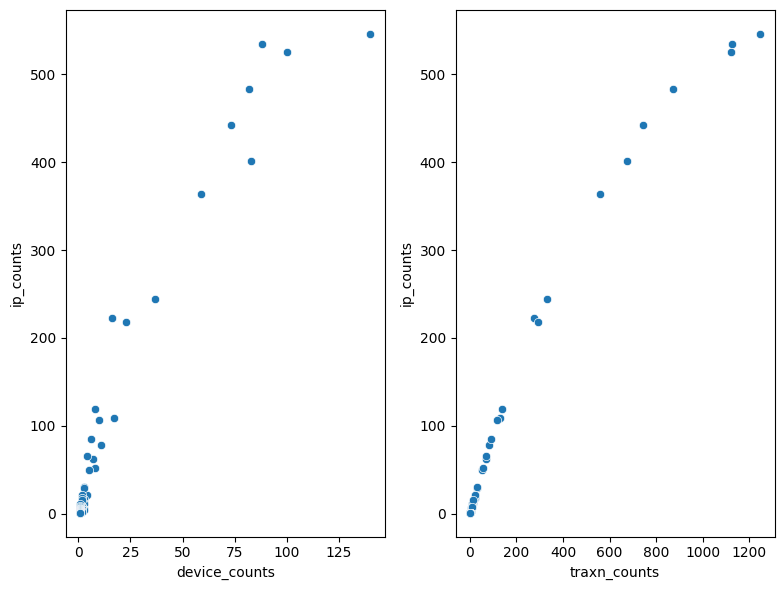

In [29]:
fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.scatterplot(data = ip_score_device, x = "device_counts", y = "ip_counts", ax = ax[0])
sns.scatterplot(data = traxn_ip_counts, x = "traxn_counts", y = "ip_counts", ax = ax[1])

plt.tight_layout()
plt.show()

In [30]:
train_valid_df.chargeback_history_count.value_counts()

chargeback_history_count
0    8930
1     221
2      72
Name: count, dtype: int64

In [31]:
train_valid_df.groupby(by = ["chargeback_history_count"])["is_fraud"].mean().round(4) * 100

chargeback_history_count
0     4.75
1    91.40
2    98.61
Name: is_fraud, dtype: float64

In [182]:
train_valid_df.groupby(by = ["customer_id"]).aggregate({"chargeback_history_count": "nunique"}).chargeback_history_count.unique()

array([1])

In [32]:
train_valid_df.loc[train_valid_df.chargeback_history_count == 1, "customer_id"].unique().tolist()[:4]

['6310c205-42bb-4295-b4dc-2a6128a1c1f0',
 '839b6a11-fede-416d-9a2d-ff4e636ce76a',
 '1f796a14-cde3-45c3-bc5e-feb6dd1846c9',
 '628d6e7a-81c1-49c4-a7c6-e56832a9ba0d']

In [33]:
train_valid_df.loc[train_valid_df.chargeback_history_count == 2, "customer_id"].unique().tolist()[:4]

['081b1e5f-9aad-440e-aac7-270f56063059',
 '93ca016d-93a2-4b86-b170-8871a9e4561e',
 '3c41d3c8-773c-44e9-a743-410f8510c3a7',
 '736dcefd-490b-4fac-b03a-6656abe0043b']

In [34]:
train_valid_df.loc[train_valid_df.customer_id == "6310c205-42bb-4295-b4dc-2a6128a1c1f0",
                   ["datetime", "chargeback_history_count"]].sort_values(by = ["datetime"], ascending = [True])

,datetime,chargeback_history_count
1345,2023-03-01 13:20:34.468549+00:00,1
6095,2023-05-23 14:20:34.468549+00:00,1
2151,2023-05-30 17:20:49.468549+00:00,1
3813,2023-11-27 06:36:52.468549+00:00,1
5623,2024-06-04 07:11:19.468549+00:00,1
5689,2024-06-12 00:33:35.468549+00:00,1
5745,2024-06-16 10:19:25.468549+00:00,1
6075,2024-07-24 14:42:12.468549+00:00,1
7065,2024-11-16 07:06:03.468549+00:00,1


In [35]:
train_valid_df.loc[train_valid_df.customer_id == "93ca016d-93a2-4b86-b170-8871a9e4561e",
                   ["datetime", "chargeback_history_count"]].sort_values(by = ["datetime"], ascending = [True])

,datetime,chargeback_history_count
8437,2023-12-05 14:58:16.573611+00:00,2


In [36]:
train_valid_df.groupby(by = ["customer_id"]).aggregate({"chargeback_history_count": "nunique"}).sort_values(by = ["chargeback_history_count"], ascending = [False])

,chargeback_history_count
customer_id,
0006f893-10a8-4235-831b-fcae1e3f0140,1
a99be66c-abef-4b14-9d0b-c83b30d659a3,1
a69c995e-c380-4fe5-ab91-7c9da5116013,1
a6aa2e61-f9e4-485f-9661-f1aa5ae69410,1
a6d0c468-d8b1-4b7b-bf30-b428005cfb1e,1
...,...
55ce2ee2-d3b9-4aa5-9094-88e46abba67f,1
55de73b9-6abe-4977-98fe-6ce602b2c9a3,1
561b28eb-1c5b-4d1f-946b-f354fd8e69e0,1


In [37]:
train_valid_df.groupby(by = ["customer_id"]).aggregate({"risk_score_internal": "nunique"}).risk_score_internal.unique()

array([1])

In [38]:
train_valid_df.corridor_risk.value_counts(normalize = True).round(4) * 100

corridor_risk
0.00    75.01
0.25     8.70
0.10     7.91
0.20     3.89
0.22     2.28
0.12     1.29
0.05     0.92
Name: proportion, dtype: float64

In [39]:
train_valid_df.groupby(by = ["customer_id"]).aggregate({"corridor_risk": "nunique"}).corridor_risk.unique()

array([1, 4, 2, 3])

In [40]:
corridor_risk = train_valid_df.groupby(by = ["customer_id"]).aggregate({"corridor_risk": "nunique"}).sort_values(by = ["corridor_risk"], ascending = [False])
corridor_risk.head()

,corridor_risk
customer_id,
4cfe5cbc-d677-49bc-8739-b1d05f351250,4
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,4
07581610-391c-4938-acf4-39c7c272fc39,4
402cccc9-28de-45b3-9af7-cc5302aa1f93,4
af8ca4c4-8703-4c55-b66c-2b76cd70040d,4


In [41]:
train_valid_df.loc[
    train_valid_df.customer_id == "4cfe5cbc-d677-49bc-8739-b1d05f351250",
    ["datetime", "corridor_risk"]
].head(20)

,datetime,corridor_risk
5,2022-10-04 12:09:59.468549+00:00,0.00
82,2022-10-13 00:56:51.468549+00:00,0.10
90,2022-10-14 18:30:45.468549+00:00,0.00
362,2022-11-14 00:19:28.468549+00:00,0.10
525,2022-12-03 11:10:57.468549+00:00,0.10
569,2022-12-08 02:32:08.468549+00:00,0.20
747,2022-12-26 23:00:40.468549+00:00,0.25
1011,2023-01-24 10:11:25.468549+00:00,0.00
1327,2023-02-27 05:42:38.468549+00:00,0.00
1367,2023-03-04 06:50:07.468549+00:00,0.25


In [42]:
train_valid_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022-10-03 18:40:59.468549+00:00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022-10-03 20:39:38.468549+00:00
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022-10-03 23:02:43.468549+00:00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022-10-04 01:08:53.468549+00:00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022-10-04 09:35:03.468549+00:00


In [184]:
not_fraud = train_valid_df.loc[train_valid_df.is_fraud == 0, "chargeback_history_count"].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = train_valid_df.loc[train_valid_df.is_fraud == 1, "chargeback_history_count"].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

In [186]:
chargeback = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)
chargeback

,chargeback_history_count,count,target
0,0,8506,not_fraud
1,1,19,not_fraud
2,2,1,not_fraud
0,0,424,fraud
1,1,202,fraud
2,2,71,fraud


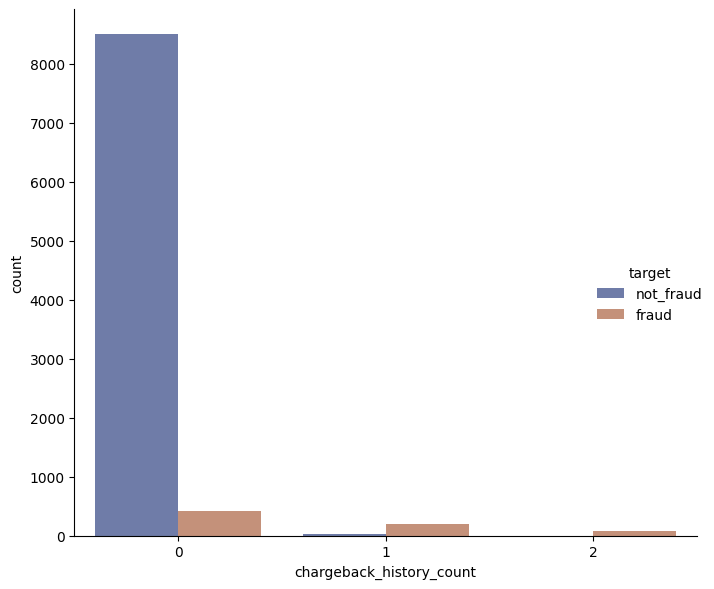

In [187]:
sns.catplot(data = chargeback, x = "chargeback_history_count", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6,
            height = 6)

plt.tight_layout()
plt.show()

In [188]:
chargeback_woe = pd.crosstab(
    index = train_valid_df.chargeback_history_count,
    columns = train_valid_df.is_fraud
)

chargeback_woe.columns.name = None
chargeback_woe.columns = ["not_fraud", "fraud"]
chargeback_woe["proportion_not_fraud"] = chargeback_woe.not_fraud / chargeback_woe.not_fraud.sum()
chargeback_woe["proportion_fraud"] = chargeback_woe.fraud / chargeback_woe.fraud.sum()
chargeback_woe["woe"] = np.log(chargeback_woe.proportion_fraud / chargeback_woe.proportion_not_fraud)
chargeback_woe["iv"] = (chargeback_woe.proportion_fraud - chargeback_woe.proportion_not_fraud) * chargeback_woe.woe

information_value = chargeback_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

chargeback_woe

Information Value: 2.281


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
chargeback_history_count,,,,,,
0,8506,424,0.997654,0.608321,-0.494703,0.192604
1,19,202,0.002228,0.289813,4.867919,1.399941
2,1,71,0.000117,0.101865,6.766770,0.688504


In [189]:
table = pd.crosstab(
    index = train_valid_df.chargeback_history_count,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
0,8506,424
1,19,202
2,1,71


In [190]:
chi2, p, _, _, = chi2_contingency(table)
n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.587)

In [43]:
train_valid_df.channel.value_counts()

channel
mobile       5085
web          3048
ATM           842
mobille        47
 mobile        38
MOBILE         36
unknown        33
 web           30
WEB            29
weeb           22
ATm             9
 ATM            4
Name: count, dtype: int64

In [44]:
train_valid_df.channel.str.strip().str.lower().value_counts()

channel
mobile     5159
web        3107
atm         855
mobille      47
unknown      33
weeb         22
Name: count, dtype: int64

In [45]:
def patch_channel(channel: str, options: list = ["mobile", "web", "atm"]) -> str:
    compare = {c: w for c in options if (w:=Levenshtein.ratio(c, channel)) >= 0.80}
    if not compare:
        return "unknown"
    return sorted(compare, key = lambda x: compare.get(x), reverse = False)[0]

In [46]:
train_valid_df.channel = train_valid_df.channel.str.strip().str.lower().apply(lambda x: patch_channel(x))

In [47]:
test_df.channel = test_df.channel.str.strip().str.lower().apply(lambda x: patch_channel(x))

In [48]:
train_valid_df.channel.value_counts()

channel
mobile     5206
web        3129
atm         855
unknown      33
Name: count, dtype: int64

In [49]:
not_fraud = train_valid_df.loc[train_valid_df.is_fraud == 0, "channel"].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = train_valid_df.loc[train_valid_df.is_fraud == 1, "channel"].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

In [50]:
channel_distro = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)

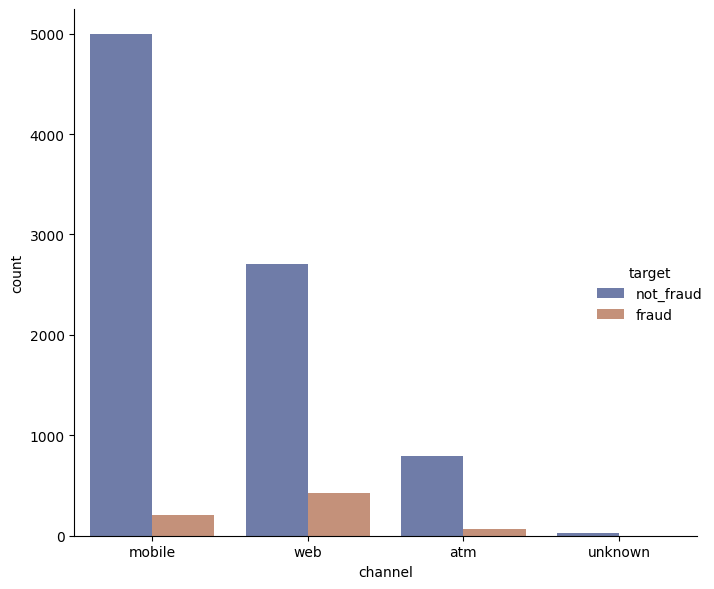

In [51]:
sns.catplot(data = channel_distro, x = "channel", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6,
            height = 6)

plt.tight_layout()
plt.show()

In [52]:
channel_woe = pd.crosstab(
    index = train_valid_df.channel,
    columns = train_valid_df.is_fraud
)

channel_woe.columns.name = None
channel_woe.columns = ["not_fraud", "fraud"]
channel_woe["proportion_not_fraud"] = channel_woe.not_fraud / channel_woe.not_fraud.sum()
channel_woe["proportion_fraud"] = channel_woe.fraud / channel_woe.fraud.sum()
channel_woe["woe"] = np.log(channel_woe.proportion_fraud / channel_woe.proportion_not_fraud)
channel_woe["iv"] = (channel_woe.proportion_fraud - channel_woe.proportion_not_fraud) * channel_woe.woe

information_value = channel_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

channel_woe

Information Value: 0.377


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
channel,,,,,,
atm,793,62,0.093010,0.088953,-0.044599,0.000181
mobile,4995,211,0.585855,0.302726,-0.660244,0.186934
unknown,32,1,0.003753,0.001435,-0.961646,0.002230
web,2706,423,0.317382,0.606887,0.648236,0.187667


In [53]:
table = pd.crosstab(
    index = train_valid_df.channel,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
atm,793,62
mobile,4995,211
unknown,32,1
web,2706,423


In [54]:
chi2, p, _, _ = chi2_contingency(table)

In [55]:
n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.165)

In [56]:
train_valid_df.source_currency.unique()

<StringArray>
['USD', 'CAD', 'GBP']
Length: 3, dtype: str

In [57]:
train_valid_df.groupby(by = ["home_country"]).aggregate({"source_currency": "unique"})

,source_currency
home_country,
CA,[CAD]
UK,[GBP]
US,[USD]


In [58]:
new_device = pd.crosstab(
    index = train_valid_df.new_device,
    columns = train_valid_df.is_fraud
)

new_device.index.name = None
new_device.columns.name = None

new_device.columns = ["not_fraud", "fraud"]

chi2, p, _, _ = chi2_contingency(new_device)

n = table.sum().sum()
phi = np.sqrt(chi2 / n)

phi.round(4)

np.float64(0.3397)

In [59]:
new_device_woe = pd.crosstab(
    index = train_valid_df.new_device,
    columns = train_valid_df.is_fraud
)

new_device_woe.columns.name = None
new_device_woe.columns = ["not_fraud", "fraud"]
new_device_woe["proportion_not_fraud"] = new_device_woe.not_fraud / new_device_woe.not_fraud.sum()
new_device_woe["proportion_fraud"] = new_device_woe.fraud / new_device_woe.fraud.sum()
new_device_woe["woe"] = np.log(new_device_woe.proportion_fraud / new_device_woe.proportion_not_fraud)
new_device_woe["iv"] = (new_device_woe.proportion_fraud - new_device_woe.proportion_not_fraud) * new_device_woe.woe

information_value = new_device_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

new_device_woe

Information Value: 0.963


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
new_device,,,,,,
False,7836,358,0.919071,0.51363,-0.581861,0.235910
True,690,339,0.080929,0.48637,1.793399,0.727118


In [60]:
not_fraud = train_valid_df.loc[train_valid_df.is_fraud == 0, "new_device"].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = train_valid_df.loc[train_valid_df.is_fraud == 1, "new_device"].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

new_device_distro = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)

In [61]:
new_device_distro

,new_device,count,target
0,False,7836,not_fraud
1,True,690,not_fraud
0,False,358,fraud
1,True,339,fraud


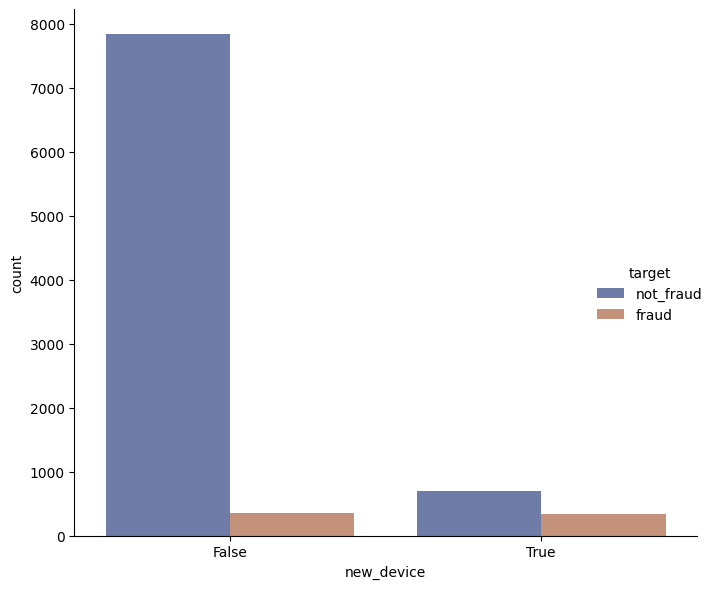

In [62]:
sns.catplot(data = new_device_distro, x = "new_device", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6, height = 6,  ax = ax)

plt.tight_layout()
plt.show()

In [63]:
location_mismatch = pd.crosstab(
    index = train_valid_df.location_mismatch,
    columns = train_valid_df.is_fraud
)

location_mismatch.index.name = None
location_mismatch.columns.name = None

location_mismatch.columns = ["not_fraud", "fraud"]

chi2, p, _, _ = chi2_contingency(location_mismatch)

n = table.sum().sum()
phi = np.sqrt(chi2 / n)

phi.round(4)

np.float64(0.3778)

In [64]:
location_mismatch_woe = pd.crosstab(
    index = train_valid_df.location_mismatch,
    columns = train_valid_df.is_fraud
)

location_mismatch_woe.columns.name = None
location_mismatch_woe.columns = ["not_fraud", "fraud"]
location_mismatch_woe["proportion_not_fraud"] = location_mismatch_woe.not_fraud / location_mismatch_woe.not_fraud.sum()
location_mismatch_woe["proportion_fraud"] = location_mismatch_woe.fraud / location_mismatch_woe.fraud.sum()
location_mismatch_woe["woe"] = np.log(location_mismatch_woe.proportion_fraud / location_mismatch_woe.proportion_not_fraud)
location_mismatch_woe["iv"] = (location_mismatch_woe.proportion_fraud - location_mismatch_woe.proportion_not_fraud) * location_mismatch_woe.woe

information_value = location_mismatch_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

location_mismatch_woe

Information Value: 1.33


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
location_mismatch,,,,,,
False,7552,258,0.885761,0.370158,-0.872518,0.449873
True,974,439,0.114239,0.629842,1.707178,0.880227


In [65]:
not_fraud = train_valid_df.loc[train_valid_df.is_fraud == 0, "location_mismatch"].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = train_valid_df.loc[train_valid_df.is_fraud == 1, "location_mismatch"].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

location_mismatch_distro = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)

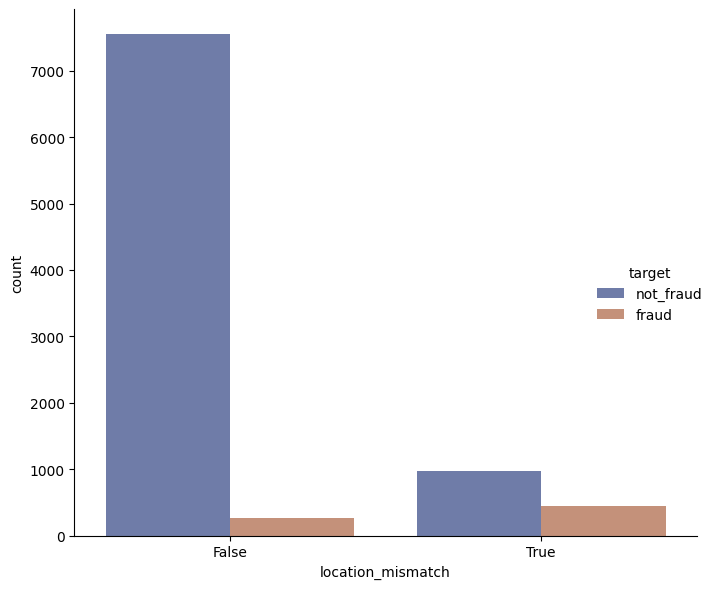

In [66]:
sns.catplot(data = location_mismatch_distro, x = "location_mismatch", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6, height = 6,  ax = ax)

plt.tight_layout()
plt.show()

In [67]:
train_valid_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022-10-03 18:40:59.468549+00:00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022-10-03 20:39:38.468549+00:00
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022-10-03 23:02:43.468549+00:00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022-10-04 01:08:53.468549+00:00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022-10-04 09:35:03.468549+00:00


In [68]:
table = pd.crosstab(
    index = train_valid_df.kyc_tier,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
enhanced,1549,27
low,430,347
standard,6547,323


In [69]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.428)

In [70]:
kyc_woe = pd.crosstab(
    index = train_valid_df.kyc_tier,
    columns = train_valid_df.is_fraud
)

kyc_woe.columns.name = None
kyc_woe.columns = ["not_fraud", "fraud"]
kyc_woe["proportion_not_fraud"] = kyc_woe.not_fraud / kyc_woe.not_fraud.sum()
kyc_woe["proportion_fraud"] = kyc_woe.fraud / kyc_woe.fraud.sum()
kyc_woe["woe"] = np.log(kyc_woe.proportion_fraud / kyc_woe.proportion_not_fraud)
kyc_woe["iv"] = (kyc_woe.proportion_fraud - kyc_woe.proportion_not_fraud) * kyc_woe.woe

information_value = kyc_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

kyc_woe

Information Value: 1.399


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
kyc_tier,,,,,,
enhanced,1549,27,0.181680,0.038737,-1.545438,0.220908
low,430,347,0.050434,0.497848,2.289630,1.024412
standard,6547,323,0.767886,0.463415,-0.505020,0.153764


In [71]:
not_fraud = train_valid_df.loc[train_valid_df.is_fraud == 0, "kyc_tier"].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = train_valid_df.loc[train_valid_df.is_fraud == 1, "kyc_tier"].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

kyc_distro = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)

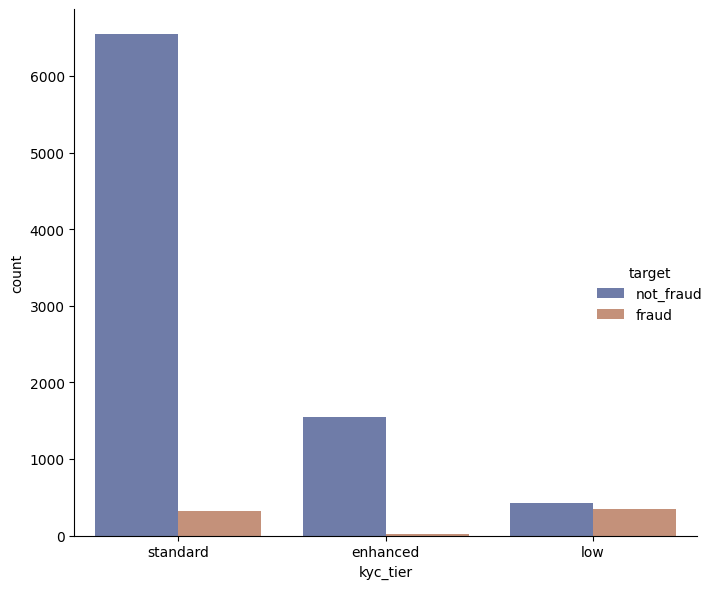

In [72]:
sns.catplot(data = kyc_distro, x = "kyc_tier", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6, height = 6,  ax = ax)

plt.tight_layout()
plt.show()

In [73]:
table = pd.crosstab(
    index = train_valid_df.corridor_risk,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
0.00,6593,325
0.05,80,5
0.10,659,71
0.12,51,68
0.20,281,78
0.22,141,69
0.25,721,81


In [74]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.296)

In [75]:
corridor_risk_woe = pd.crosstab(
    index = train_valid_df.corridor_risk,
    columns = train_valid_df.is_fraud
)

corridor_risk_woe.columns.name = None
corridor_risk_woe.columns = ["not_fraud", "fraud"]
corridor_risk_woe["proportion_not_fraud"] = corridor_risk_woe.not_fraud / corridor_risk_woe.not_fraud.sum()
corridor_risk_woe["proportion_fraud"] = corridor_risk_woe.fraud / corridor_risk_woe.fraud.sum()
corridor_risk_woe["woe"] = np.log(corridor_risk_woe.proportion_fraud / corridor_risk_woe.proportion_not_fraud)
corridor_risk_woe["iv"] = (corridor_risk_woe.proportion_fraud - corridor_risk_woe.proportion_not_fraud) * corridor_risk_woe.woe

information_value = corridor_risk_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

corridor_risk_woe

Information Value: 0.672


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
corridor_risk,,,,,,
0.00,6593,325,0.773282,0.466284,-0.505848,0.155294
0.05,80,5,0.009383,0.007174,-0.268499,0.000593
0.10,659,71,0.077293,0.101865,0.276047,0.006783
0.12,51,68,0.005982,0.097561,2.791772,0.255668
0.20,281,78,0.032958,0.111908,1.222444,0.096512
0.22,141,69,0.016538,0.098996,1.789437,0.147553
0.25,721,81,0.084565,0.116212,0.317900,0.010061


In [76]:
not_fraud = train_valid_df.loc[train_valid_df.is_fraud == 0, "corridor_risk"].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = train_valid_df.loc[train_valid_df.is_fraud == 1, "corridor_risk"].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

corridor_risk_distro = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)

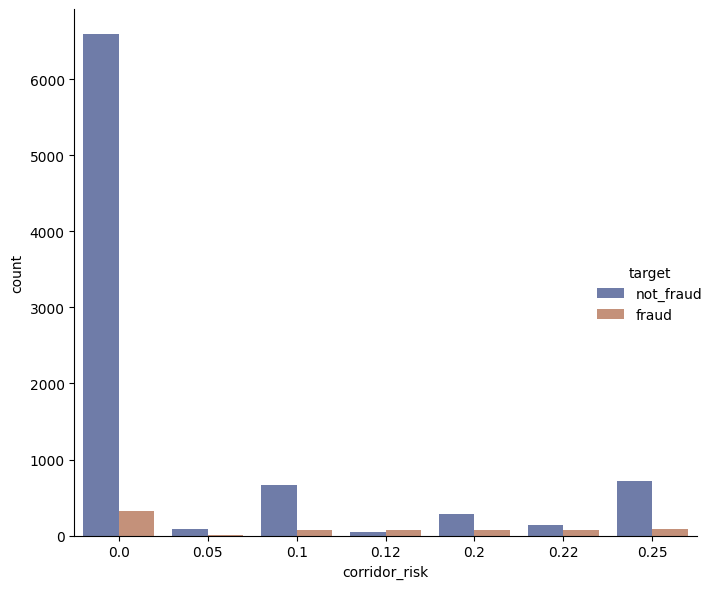

In [77]:
sns.catplot(data = corridor_risk_distro, x = "corridor_risk", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6, height = 6,  ax = ax)

plt.tight_layout()
plt.show()

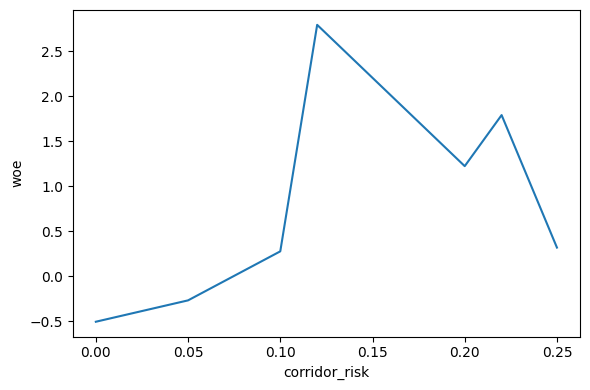

In [78]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(data = corridor_risk_woe.woe.to_frame().reset_index(), x = "corridor_risk", y = "woe", ax = ax)

plt.tight_layout()
plt.show()

In [79]:
cat = pd.cut(
    train_valid_df.corridor_risk,
    bins = [0, 0.10, 0.19, 1],
    labels = ["low", "mid", "high"],
    include_lowest = True
)

In [80]:
table = pd.crosstab(
    index = cat,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
low,7332,401
mid,51,68
high,1143,228


In [81]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.264)

In [82]:
corridor_risk_woe = pd.crosstab(
    index = cat,
    columns = train_valid_df.is_fraud
)

corridor_risk_woe.columns.name = None
corridor_risk_woe.columns = ["not_fraud", "fraud"]
corridor_risk_woe["proportion_not_fraud"] = corridor_risk_woe.not_fraud / corridor_risk_woe.not_fraud.sum()
corridor_risk_woe["proportion_fraud"] = corridor_risk_woe.fraud / corridor_risk_woe.fraud.sum()
corridor_risk_woe["woe"] = np.log(corridor_risk_woe.proportion_fraud / corridor_risk_woe.proportion_not_fraud)
corridor_risk_woe["iv"] = (corridor_risk_woe.proportion_fraud - corridor_risk_woe.proportion_not_fraud) * corridor_risk_woe.woe

information_value = corridor_risk_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

corridor_risk_woe

Information Value: 0.542


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
corridor_risk,,,,,,
low,7332,401,0.859958,0.575323,-0.401952,0.114410
mid,51,68,0.005982,0.097561,2.791772,0.255668
high,1143,228,0.134061,0.327116,0.892024,0.172210


In [83]:
not_fraud = cat[train_valid_df.is_fraud == 0].value_counts().to_frame().reset_index()
not_fraud["target"] = "not_fraud"

fraud = cat[train_valid_df.is_fraud == 1].value_counts().to_frame().reset_index()
fraud["target"] = "fraud"

corridor_risk_distro = pd.concat(
    [
        not_fraud,
        fraud
    ],
    axis = 0
)

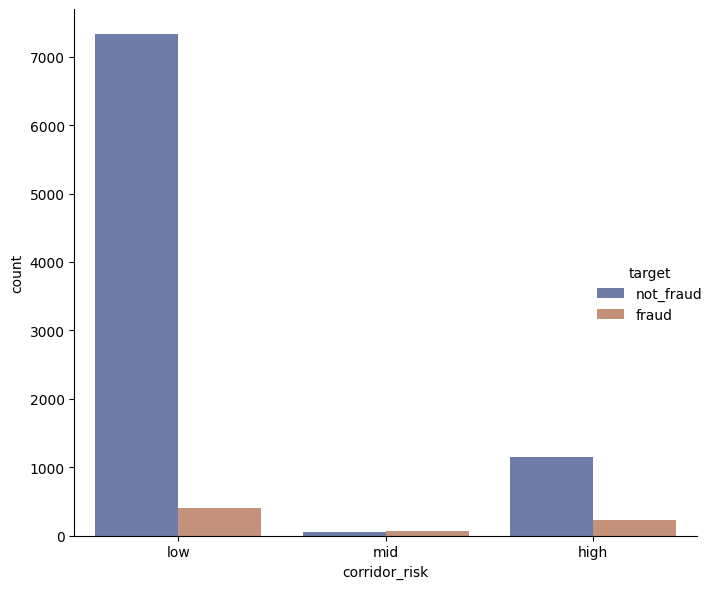

In [84]:
sns.catplot(data = corridor_risk_distro, x = "corridor_risk", y = "count", hue = "target",
            kind = "bar", errorbar = "sd", palette = "dark", alpha = .6, height = 6,  ax = ax)

plt.tight_layout()
plt.show()

In [85]:
corridor_risk_woe

,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
corridor_risk,,,,,,
low,7332,401,0.859958,0.575323,-0.401952,0.114410
mid,51,68,0.005982,0.097561,2.791772,0.255668
high,1143,228,0.134061,0.327116,0.892024,0.172210


In [86]:
table = pd.crosstab(
    index = train_valid_df.txn_velocity_1h,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
-1,163,4
0,8043,158
1,97,0
2,9,0
3,35,147
4,33,130
5,36,99
6,41,83
7,29,49
8,40,27


In [87]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.729)

In [88]:
txn_velocity_woe = pd.crosstab(
    index = train_valid_df.txn_velocity_1h,
    columns = train_valid_df.is_fraud
)

txn_velocity_woe.columns.name = None
txn_velocity_woe.columns = ["not_fraud", "fraud"]
txn_velocity_woe["proportion_not_fraud"] = txn_velocity_woe.not_fraud / txn_velocity_woe.not_fraud.sum()
txn_velocity_woe["proportion_fraud"] = txn_velocity_woe.fraud / txn_velocity_woe.fraud.sum()
txn_velocity_woe["woe"] = np.log(txn_velocity_woe.proportion_fraud / txn_velocity_woe.proportion_not_fraud)
txn_velocity_woe["iv"] = (txn_velocity_woe.proportion_fraud - txn_velocity_woe.proportion_not_fraud) * txn_velocity_woe.woe

information_value = txn_velocity_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

txn_velocity_woe

Information Value: inf


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
txn_velocity_1h,,,,,,
-1,163,4,0.019118,0.005739,-1.203366,0.016100
0,8043,158,0.943350,0.226686,-1.425872,1.021871
1,97,0,0.011377,0.000000,-inf,inf
2,9,0,0.001056,0.000000,-inf,inf
3,35,147,0.004105,0.210904,3.939175,0.814617
4,33,130,0.003871,0.186514,3.875117,0.707763
5,36,99,0.004222,0.142037,3.515691,0.484515
6,41,83,0.004809,0.119082,3.209359,0.366743
7,29,49,0.003401,0.070301,3.028615,0.202614


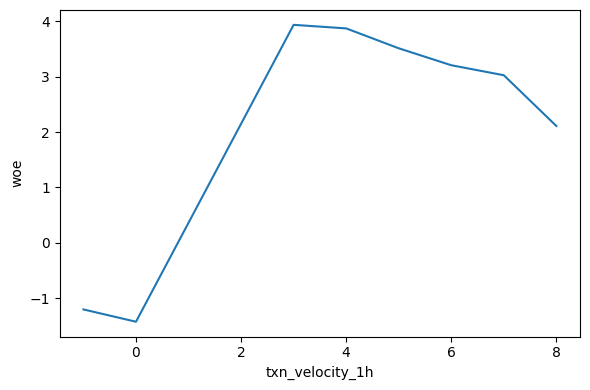

In [91]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(data = txn_velocity_woe.woe.to_frame().reset_index(), x = "txn_velocity_1h", y = "woe", ax = ax)

plt.tight_layout()
plt.show()

In [90]:
txn_velocity_cat = pd.cut(
    train_valid_df.txn_velocity_1h,
    bins = [-np.inf, 1, 4, np.inf],
    labels = ["txn_1h: <1", "txn_1h: <4", "txn_1h: >4"],
    include_lowest = True
)

In [92]:
table = pd.crosstab(
    index = txn_velocity_cat,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
txn_1h: <1,8303,162
txn_1h: <4,77,277
txn_1h: >4,146,258


In [105]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.718)

In [106]:
txn_velocity_woe = pd.crosstab(
    index = txn_velocity_cat,
    columns = train_valid_df.is_fraud
)

txn_velocity_woe.columns.name = None
txn_velocity_woe.columns = ["not_fraud", "fraud"]
txn_velocity_woe["proportion_not_fraud"] = txn_velocity_woe.not_fraud / txn_velocity_woe.not_fraud.sum()
txn_velocity_woe["proportion_fraud"] = txn_velocity_woe.fraud / txn_velocity_woe.fraud.sum()
txn_velocity_woe["woe"] = np.log(txn_velocity_woe.proportion_fraud / txn_velocity_woe.proportion_not_fraud)
txn_velocity_woe["iv"] = (txn_velocity_woe.proportion_fraud - txn_velocity_woe.proportion_not_fraud) * txn_velocity_woe.woe

information_value = txn_velocity_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

txn_velocity_woe

Information Value: 3.617


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
txn_velocity_1h,,,,,,
txn_1h: <1,8303,162,0.973845,0.232425,-1.432686,1.062222
txn_1h: <4,77,277,0.009031,0.397418,3.784302,1.469771
txn_1h: >4,146,258,0.017124,0.370158,3.073443,1.085029


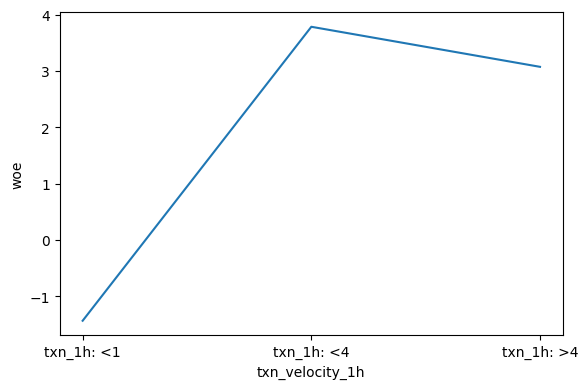

In [107]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(data = txn_velocity_woe.woe.to_frame().reset_index(), x = "txn_velocity_1h", y = "woe", ax = ax)

plt.tight_layout()
plt.show()

In [108]:
table = pd.crosstab(
    index = train_valid_df.txn_velocity_24h,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
0,7492,148
1,664,14
2,122,0
3,55,2
4,45,52
5,33,81
6,44,135
7,29,104
8,40,73
9,2,60


In [109]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.739)

In [110]:
txn_velocity_woe = pd.crosstab(
    index = train_valid_df.txn_velocity_24h,
    columns = train_valid_df.is_fraud
)

txn_velocity_woe.columns.name = None
txn_velocity_woe.columns = ["not_fraud", "fraud"]
txn_velocity_woe["proportion_not_fraud"] = txn_velocity_woe.not_fraud / txn_velocity_woe.not_fraud.sum()
txn_velocity_woe["proportion_fraud"] = txn_velocity_woe.fraud / txn_velocity_woe.fraud.sum()
txn_velocity_woe["woe"] = np.log(txn_velocity_woe.proportion_fraud / txn_velocity_woe.proportion_not_fraud)
txn_velocity_woe["iv"] = (txn_velocity_woe.proportion_fraud - txn_velocity_woe.proportion_not_fraud) * txn_velocity_woe.woe

information_value = txn_velocity_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

txn_velocity_woe

Information Value: inf


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
txn_velocity_24h,,,,,,
0,7492,148,0.878724,0.212339,-1.420289,0.946459
1,664,14,0.077879,0.020086,-1.355135,0.078318
2,122,0,0.014309,0.000000,-inf,inf
3,55,2,0.006451,0.002869,-0.810096,0.002901
4,45,52,0.005278,0.074605,2.648671,0.183626
5,33,81,0.003871,0.116212,3.402032,0.382190
6,44,135,0.005161,0.193687,3.625175,0.683442
7,29,104,0.003401,0.149211,3.781185,0.551333
8,40,73,0.004692,0.104735,3.105670,0.310701


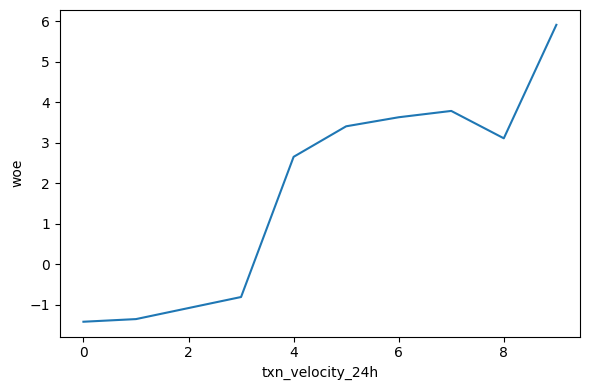

In [111]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(data = txn_velocity_woe.woe.to_frame().reset_index(), x = "txn_velocity_24h", y = "woe", ax = ax)

plt.tight_layout()
plt.show()

In [119]:
txn_velocity_cat = pd.cut(
    train_valid_df.txn_velocity_24h,
    bins = [-np.inf, 1, 3, 8, np.inf],
    labels = ["txn_24h: <1", "txn_24h: <3", "txn_24h: <8", "txn_24h: >8"],
    include_lowest = True
)

In [123]:
table = pd.crosstab(
    index = txn_velocity_cat,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
txn_24h: <1,8156,162
txn_24h: <3,177,2
txn_24h: <8,191,445
txn_24h: >8,2,88


In [124]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.735)

In [125]:
txn_velocity_woe = pd.crosstab(
    index = txn_velocity_cat,
    columns = train_valid_df.is_fraud
)

txn_velocity_woe.columns.name = None
txn_velocity_woe.columns = ["not_fraud", "fraud"]
txn_velocity_woe["proportion_not_fraud"] = txn_velocity_woe.not_fraud / txn_velocity_woe.not_fraud.sum()
txn_velocity_woe["proportion_fraud"] = txn_velocity_woe.fraud / txn_velocity_woe.fraud.sum()
txn_velocity_woe["woe"] = np.log(txn_velocity_woe.proportion_fraud / txn_velocity_woe.proportion_not_fraud)
txn_velocity_woe["iv"] = (txn_velocity_woe.proportion_fraud - txn_velocity_woe.proportion_not_fraud) * txn_velocity_woe.woe

information_value = txn_velocity_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

txn_velocity_woe

Information Value: 3.916


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
txn_velocity_24h,,,,,,
txn_24h: <1,8156,162,0.956603,0.232425,-1.414823,1.024584
txn_24h: <3,177,2,0.020760,0.002869,-1.978912,0.035404
txn_24h: <8,191,445,0.022402,0.638451,3.349891,2.063695
txn_24h: >8,2,88,0.000235,0.126255,6.288280,0.792454


In [126]:
train_valid_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022-10-03 18:40:59.468549+00:00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022-10-03 20:39:38.468549+00:00
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022-10-03 23:02:43.468549+00:00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022-10-04 01:08:53.468549+00:00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022-10-04 09:35:03.468549+00:00


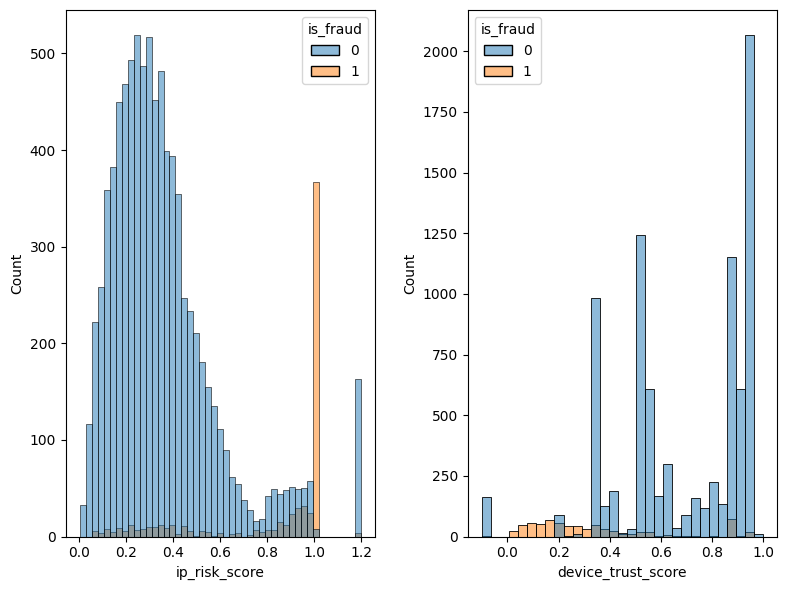

In [130]:
fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.histplot(data = train_valid_df.loc[:, ["ip_risk_score", "is_fraud"]], x = "ip_risk_score", hue = "is_fraud", ax = ax[0])
sns.histplot(data = train_valid_df.loc[:, ["device_trust_score", "is_fraud"]], x = "device_trust_score", hue = "is_fraud", ax = ax[1])

plt.tight_layout()
plt.show()

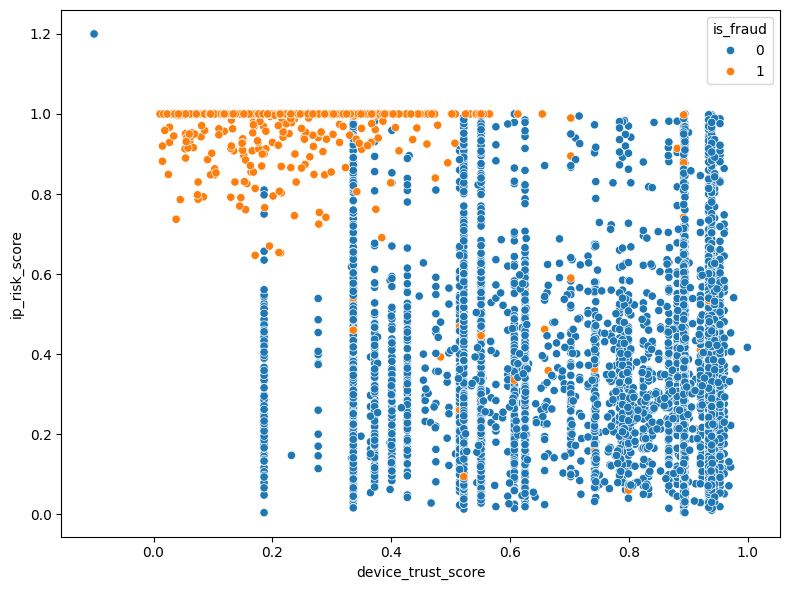

In [138]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.scatterplot(data = train_valid_df.loc[:, ["device_trust_score", "ip_risk_score", "is_fraud"]],
                x = "device_trust_score", y = "ip_risk_score", hue = "is_fraud", ax = ax)


plt.tight_layout()
plt.show()

In [141]:
corr, p = pointbiserialr(
    train_valid_df.is_fraud,
    train_valid_df.ip_risk_score
)

corr, p

(np.float64(0.4704679595873618), np.float64(0.0))

In [142]:
corr, p = pointbiserialr(
    train_valid_df.is_fraud,
    train_valid_df.device_trust_score
)

corr, p

(np.float64(-0.34387516255321504), np.float64(2.4990818480754805e-254))

In [198]:
pd.qcut(
    train_valid_df.ip_risk_score,
    10
).value_counts()

ip_risk_score
(0.003, 0.126]    934
(0.182, 0.23]     927
(0.322, 0.372]    927
(0.275, 0.322]    923
(0.372, 0.433]    923
(0.869, 1.2]      923
(0.126, 0.182]    918
(0.433, 0.535]    918
(0.23, 0.275]     915
(0.535, 0.869]    915
Name: count, dtype: int64

In [205]:
device_trust_score_bin = pd.qcut(
    train_valid_df.device_trust_score,
    5
)

device_trust_score_bin.value_counts()

device_trust_score
(0.551, 0.892]     2494
(0.372, 0.551]     2165
(-0.101, 0.372]    1855
(0.934, 0.999]     1426
(0.892, 0.934]     1283
Name: count, dtype: int64

In [210]:
table = pd.crosstab(
    index = device_trust_score_bin,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
"(-0.101, 0.372]",1372,483
"(0.372, 0.551]",2070,95
"(0.551, 0.892]",2397,97
"(0.892, 0.934]",1267,16
"(0.934, 0.999]",1420,6


In [211]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.355)

In [212]:
ip_risk_score_bin = pd.qcut(
    train_valid_df.ip_risk_score,
    10
)

ip_risk_score_bin.value_counts()

ip_risk_score
(0.003, 0.126]    934
(0.182, 0.23]     927
(0.322, 0.372]    927
(0.275, 0.322]    923
(0.372, 0.433]    923
(0.869, 1.2]      923
(0.126, 0.182]    918
(0.433, 0.535]    918
(0.23, 0.275]     915
(0.535, 0.869]    915
Name: count, dtype: int64

In [213]:
table = pd.crosstab(
    index = ip_risk_score_bin,
    columns = train_valid_df.is_fraud
)

table.columns.name = None
table.index.name = None
table.columns = ["not_fraud", "fraud"]
table

,not_fraud,fraud
"(0.003, 0.126]",918,16
"(0.126, 0.182]",902,16
"(0.182, 0.23]",910,17
"(0.23, 0.275]",901,14
"(0.275, 0.322]",905,18
"(0.322, 0.372]",908,19
"(0.372, 0.433]",902,21
"(0.433, 0.535]",894,24
"(0.535, 0.869]",857,58
"(0.869, 1.2]",429,494


In [214]:
chi2, p, _, _, = chi2_contingency(table)

n = table.sum().sum()
k = table.shape[1]

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

cramers_v.round(3)

np.float64(0.582)

In [216]:
device_trust_score_bin_woe = pd.crosstab(
    index = device_trust_score_bin,
    columns = train_valid_df.is_fraud
)

device_trust_score_bin_woe.columns.name = None
device_trust_score_bin_woe.columns = ["not_fraud", "fraud"]
device_trust_score_bin_woe["proportion_not_fraud"] = device_trust_score_bin_woe.not_fraud / device_trust_score_bin_woe.not_fraud.sum()
device_trust_score_bin_woe["proportion_fraud"] = device_trust_score_bin_woe.fraud / device_trust_score_bin_woe.fraud.sum()
device_trust_score_bin_woe["woe"] = np.log(device_trust_score_bin_woe.proportion_fraud / device_trust_score_bin_woe.proportion_not_fraud)
device_trust_score_bin_woe["iv"] = (device_trust_score_bin_woe.proportion_fraud - device_trust_score_bin_woe.proportion_not_fraud) * device_trust_score_bin_woe.woe

information_value = device_trust_score_bin_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

device_trust_score_bin_woe

Information Value: 1.641


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
device_trust_score,,,,,,
"(-0.101, 0.372]",1372,483,0.160920,0.692970,1.460082,0.776837
"(0.372, 0.551]",2070,95,0.242787,0.136298,-0.577337,0.061480
"(0.551, 0.892]",2397,97,0.281140,0.139168,-0.703172,0.099831
"(0.892, 0.934]",1267,16,0.148604,0.022956,-1.867728,0.234678
"(0.934, 0.999]",1420,6,0.166549,0.008608,-2.962562,0.467910


In [218]:
device_trust_score_bin_woe.woe.to_frame().reset_index()

,device_trust_score,woe
0,"(-0.101, 0.372]",1.460082
1,"(0.372, 0.551]",-0.577337
2,"(0.551, 0.892]",-0.703172
3,"(0.892, 0.934]",-1.867728
4,"(0.934, 0.999]",-2.962562


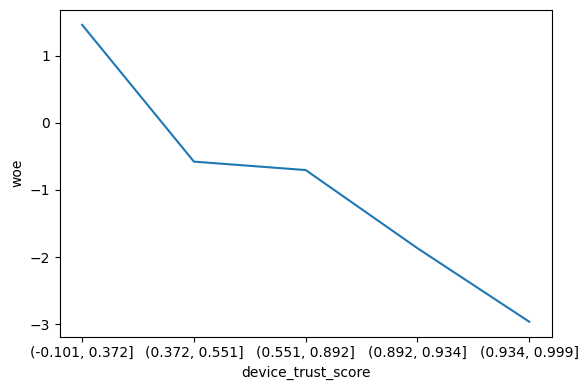

In [222]:
data = device_trust_score_bin_woe.woe.to_frame().reset_index()

data.device_trust_score = data.device_trust_score.astype(str)

fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(data = data, x = "device_trust_score", y = "woe", ax = ax)

plt.tight_layout()
plt.show()

In [223]:
ip_risk_score_bin_woe = pd.crosstab(
    index = ip_risk_score_bin,
    columns = train_valid_df.is_fraud
)

ip_risk_score_bin_woe.columns.name = None
ip_risk_score_bin_woe.columns = ["not_fraud", "fraud"]
ip_risk_score_bin_woe["proportion_not_fraud"] = ip_risk_score_bin_woe.not_fraud / ip_risk_score_bin_woe.not_fraud.sum()
ip_risk_score_bin_woe["proportion_fraud"] = ip_risk_score_bin_woe.fraud / ip_risk_score_bin_woe.fraud.sum()
ip_risk_score_bin_woe["woe"] = np.log(ip_risk_score_bin_woe.proportion_fraud / ip_risk_score_bin_woe.proportion_not_fraud)
ip_risk_score_bin_woe["iv"] = (ip_risk_score_bin_woe.proportion_fraud - ip_risk_score_bin_woe.proportion_not_fraud) * ip_risk_score_bin_woe.woe

information_value = ip_risk_score_bin_woe.iv.sum().round(3)

print(f"Information Value: {information_value}")

ip_risk_score_bin_woe

Information Value: 2.661


,not_fraud,fraud,proportion_not_fraud,proportion_fraud,woe,iv
ip_risk_score,,,,,,
"(0.003, 0.126]",918,16,0.107671,0.022956,-1.545518,0.130929
"(0.126, 0.182]",902,16,0.105794,0.022956,-1.527936,0.126572
"(0.182, 0.23]",910,17,0.106732,0.024390,-1.476141,0.121549
"(0.23, 0.275]",901,14,0.105677,0.020086,-1.660358,0.142111
"(0.275, 0.322]",905,18,0.106146,0.025825,-1.413473,0.113531
"(0.322, 0.372]",908,19,0.106498,0.027260,-1.362715,0.107979
"(0.372, 0.433]",902,21,0.105794,0.030129,-1.256002,0.095035
"(0.433, 0.535]",894,24,0.104856,0.034433,-1.113562,0.078420
"(0.535, 0.869]",857,58,0.100516,0.083214,-0.188905,0.003268


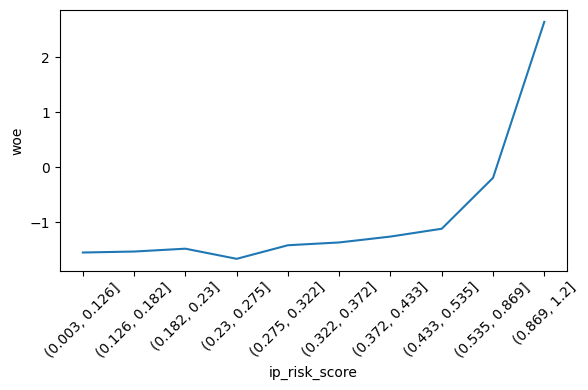

In [230]:
data = ip_risk_score_bin_woe.woe.to_frame().reset_index()

data.ip_risk_score = data.ip_risk_score.astype(str)

fig, ax = plt.subplots(figsize = (6, 4))

sns.lineplot(data = data, x = "ip_risk_score", y = "woe", ax = ax)

ax.tick_params("x", rotation = 45)

plt.tight_layout()
plt.show()

In [193]:
train_valid_df.device_trust_score

0       0.522
1       0.475
2       0.939
3       0.551
4       0.894
        ...  
9218    0.168
9219    0.152
9220    0.849
9221    0.771
9222    0.808
Name: device_trust_score, Length: 9223, dtype: float64

In [166]:
norm_amount_usd = (train_valid_df.amount_usd - train_valid_df.amount_usd.mean()) / train_valid_df.amount_usd.std()
norm_amount_usd.head()

0   -0.114352
1   -0.204065
2   -0.199691
3   -0.272765
4   -0.170272
Name: amount_usd, dtype: float64

In [167]:
corr, p = pointbiserialr(
    train_valid_df.is_fraud,
    norm_amount_usd
)

corr, p

(np.float64(0.11112305462209834), np.float64(9.792004393182484e-27))

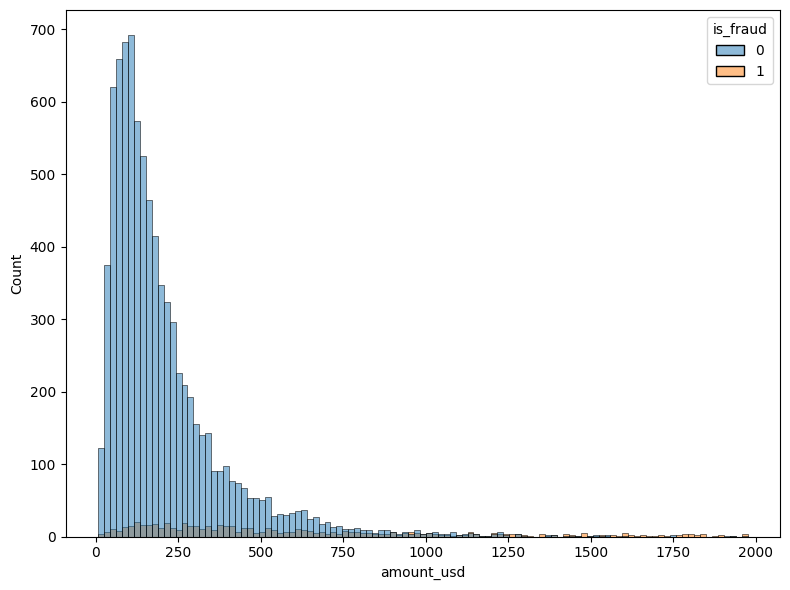

In [170]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.histplot(data = train_valid_df.loc[train_valid_df.amount_usd < 2_000, ["amount_usd", "is_fraud"]], x = "amount_usd", hue = "is_fraud", ax = ax)

plt.tight_layout()
plt.show()

In [177]:
traxn_volume = train_valid_df.groupby(by = ["customer_id"])["transaction_id"].count()

In [179]:
pd.cut(
    traxn_volume,
    bins = [0, 1, 5, 10, 20, 50, 100, np.inf],
    labels = ["0-1", "1-5", "5-10", "10-20", "20-50", "50-100", ">100"],
    include_lowest = True
).value_counts()

transaction_id
0-1       823
1-5        37
>100       13
5-10        6
10-20       6
50-100      6
20-50       4
Name: count, dtype: int64

In [180]:
train_valid_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022-10-03 18:40:59.468549+00:00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022-10-03 20:39:38.468549+00:00
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022-10-03 23:02:43.468549+00:00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022-10-04 01:08:53.468549+00:00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022-10-04 09:35:03.468549+00:00


In [191]:
predictors = [
    "chargeback_history_count",
    "channel",
    "new_device",
    "location_mismatch",
    "kyc_tier",
    "corridor_risk",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "device_trust_score",
    "ip_risk_score"
]

In [192]:
len(predictors)

10

In [153]:
train_valid_df.groupby(by = ["customer_id"])["amount_usd"].mean().isnull().sum()

np.int64(0)

In [151]:
train_valid_df.amount_usd.isnull().sum()

np.int64(0)

In [147]:
norm = train_valid_df.groupby(by = ["customer_id"])["amount_usd"].transform(lambda x: (x - x.mean()) / x.std())

In [149]:
train_valid_df.loc[norm.isnull(), "customer_id"].nunique()

823

In [150]:
train_valid_df.customer_id.nunique()

895

In [143]:
train_valid_df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,2022-10-03 18:40:59.468549+00:00
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,2022-10-03 20:39:38.468549+00:00
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,2022-10-03 23:02:43.468549+00:00
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,2022-10-04 01:08:53.468549+00:00
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,2022-10-04 09:35:03.468549+00:00
